In [1]:
# Cell 1: Imports & Parameter
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itables import init_notebook_mode, show

from utils.parquet_io import load_parquet
# >>> Pfad zu DEINEM Run anpassen:
run_dir = Path(r"C:\Dev\Bachelorarbeit\data\accounting\runs\cpcv_final\icvar_dd_ppo_S0_final\ppo_icvar_dd_state0_cpcv_20251224_090524\E2")
paths = [f"Path_{i:02d}" for i in range(1, 6)]
print(run_dir)
def load_and_info(path: Path) -> pd.DataFrame:
    """Lädt ein Parquet und gibt Infos aus."""
    df = load_parquet(path)
    print(f"\n--- {path.name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    return df


C:\Dev\Bachelorarbeit\data\accounting\runs\cpcv_final\icvar_dd_ppo_S0_final\ppo_icvar_dd_state0_cpcv_20251224_090524\E2


In [2]:
df = load_and_info(run_dir / "Path_01/rewards.parquet")
display(df.head(300), df.tail())


--- rewards.parquet ---
Shape: (1505, 18)
Columns: 18


,round,t,nav_t,nav_t-1,r_log_t,var_t,cvar_t,cvar_tminus1,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
0,1,2015-01-05 00:00:00+00:00,1.000001e+06,1.000000e+06,8.333330e-07,NaN,NaN,NaN,0.000000,0.000000,8.333330e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1,2,2015-01-06 00:00:00+00:00,1.000002e+06,1.000001e+06,8.333330e-07,NaN,NaN,NaN,0.000000,0.000000,8.333330e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
2,3,2015-01-07 00:00:00+00:00,1.000003e+06,1.000002e+06,8.333330e-07,NaN,NaN,NaN,0.000000,0.000000,8.333330e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
3,4,2015-01-08 00:00:00+00:00,1.000003e+06,1.000003e+06,8.333330e-07,NaN,NaN,NaN,0.000000,0.000000,8.333330e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
4,5,2015-01-09 00:00:00+00:00,1.000004e+06,1.000003e+06,5.555554e-07,NaN,NaN,NaN,0.000000,0.000000,5.555554e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,297,2016-03-09 00:00:00+00:00,4.230287e+06,3.607411e+06,1.592795e-01,0.117791,0.220641,0.218093,0.002548,0.000000,1.567316e-01,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
296,298,2016-03-10 00:00:00+00:00,4.094546e+06,4.230287e+06,-3.261417e-02,0.115817,0.222457,0.220641,0.001816,0.032088,-6.651853e-02,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
297,299,2016-03-11 00:00:00+00:00,4.082349e+06,4.094546e+06,-2.983295e-03,0.113844,0.223627,0.222457,0.001170,0.002883,-7.036521e-03,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
298,300,2016-03-14 00:00:00+00:00,4.342174e+06,4.082349e+06,6.170264e-02,0.111870,0.224227,0.223627,0.000600,0.000000,6.110300e-02,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1


,round,t,nav_t,nav_t-1,r_log_t,var_t,cvar_t,cvar_tminus1,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
1500,1506,2020-12-24 00:00:00+00:00,2.459851e+06,2.411180e+06,0.019984,0.047523,0.113785,0.114105,-0.000320,0.0,0.020305,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1501,1507,2020-12-28 00:00:00+00:00,2.804318e+06,2.459851e+06,0.131060,0.047464,0.113465,0.113785,-0.000320,0.0,0.131379,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1502,1508,2020-12-29 00:00:00+00:00,2.835307e+06,2.804318e+06,0.010990,0.047404,0.113146,0.113465,-0.000319,0.0,0.011309,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1503,1509,2020-12-30 00:00:00+00:00,2.988637e+06,2.835307e+06,0.052667,0.047344,0.112827,0.113146,-0.000318,0.0,0.052985,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1504,1510,2020-12-31 00:00:00+00:00,2.998503e+06,2.988637e+06,0.003296,0.047285,0.112510,0.112827,-0.000317,0.0,0.003613,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1


In [3]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


Path_01
Path_02
Path_03
Path_04
Path_05


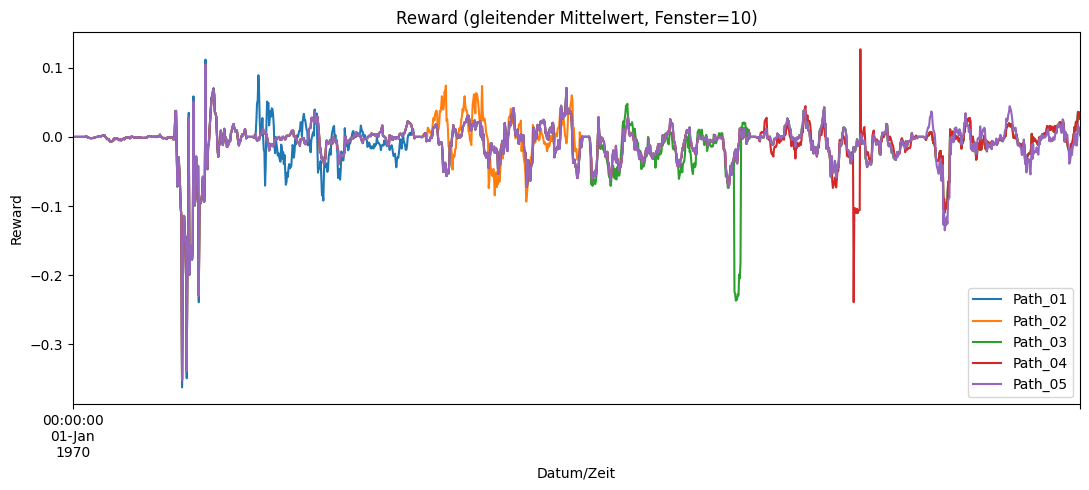

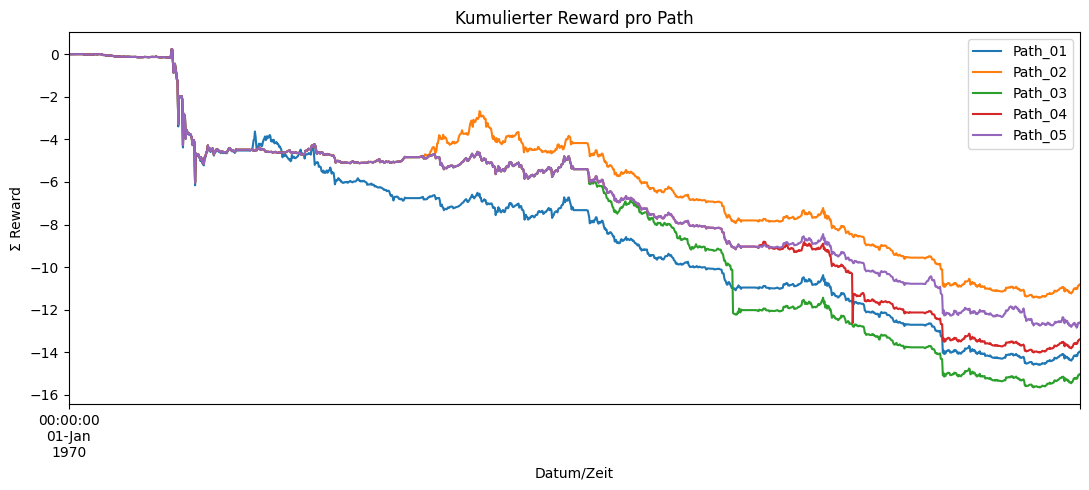

In [4]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("Reward (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Reward")
plt.tight_layout(); plt.show()

# Kumuliert:
wide_cum = wide.fillna(0).cumsum()
ax = wide_cum.plot(figsize=(11,5))
ax.set_title("Kumulierter Reward pro Path")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Σ Reward")
plt.tight_layout(); plt.show()


In [3]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:

    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["nav_t"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


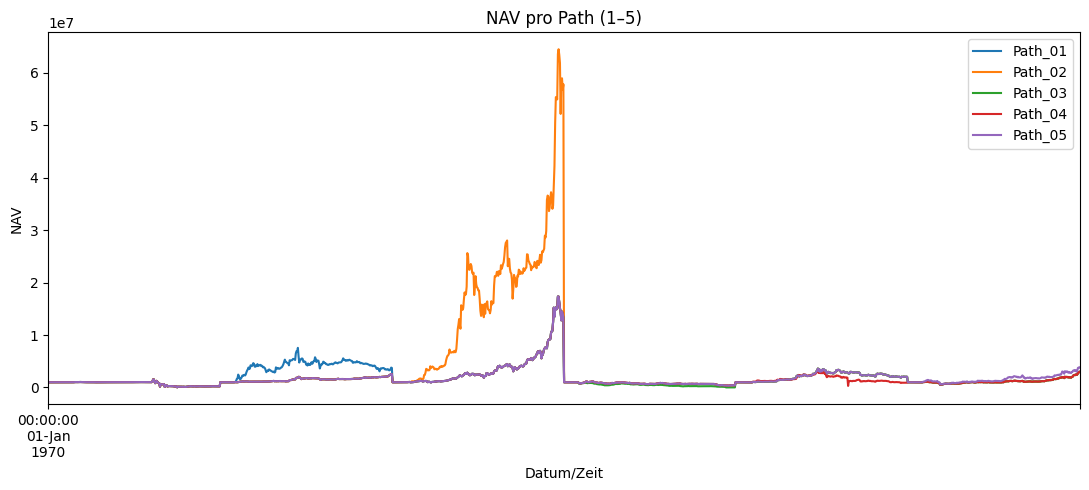

In [4]:
# Cell 3: Plot – Reward pro Path (roh)
ax = wide.plot(figsize=(11,5))
ax.set_title("NAV pro Path (1–5)")
ax.set_xlabel("Datum/Zeit")
ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()

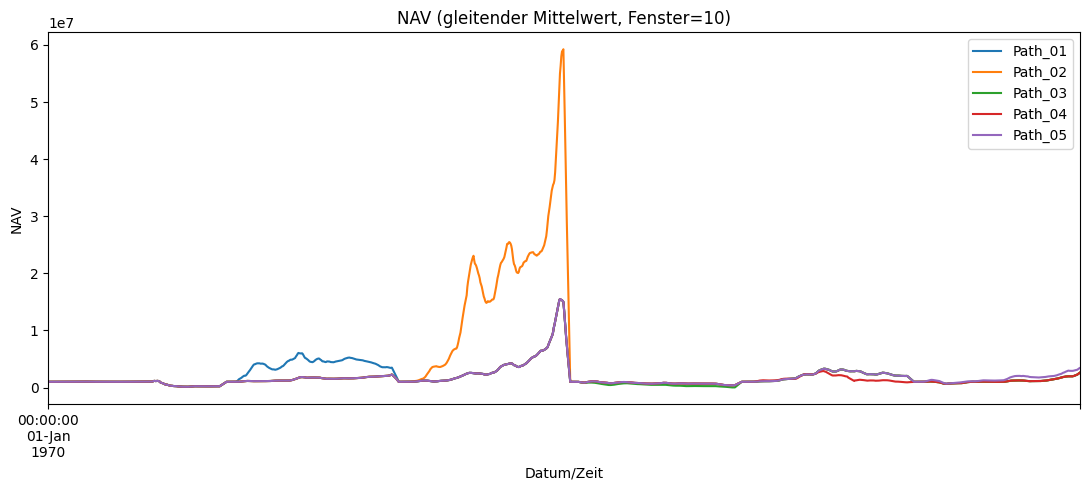

In [7]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("NAV (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()


In [5]:
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_trade   = p / "trade_events.parquet"


    if f_trade.is_file():
        df = load_parquet(f_trade)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")


df_btc = load_and_info(f_trade)
display(df_btc)

Path_01
⚠️ Keine Reward-Spalte in Path_01
Path_02
⚠️ Keine Reward-Spalte in Path_02
Path_03
⚠️ Keine Reward-Spalte in Path_03
Path_04
⚠️ Keine Reward-Spalte in Path_04
Path_05
⚠️ Keine Reward-Spalte in Path_05

--- trade_events.parquet ---
Shape: (69, 11)
Columns: 11


,asset,q,adj_open,p_exec,notional_abs,spread_cost,fees,vol_slip,total_cost,round,t
0,BTC-USD,589.578561,218.039993,218.367053,128744.533024,192.827560,321.861333,0.0,321.861333,20,2015-02-02 00:00:00+00:00
1,BTC-USD,-17.785030,266.219330,265.820001,4727.616808,7.102078,11.819042,0.0,11.819042,152,2015-08-11 00:00:00+00:00
2,ETH-USD,280060.316460,1.050000,1.051575,294504.413911,441.094982,736.261035,0.0,736.261035,153,2015-08-12 00:00:00+00:00
3,ETH-USD,243919.926558,1.300000,1.301950,317571.536738,475.643843,793.928842,0.0,793.928842,154,2015-08-13 00:00:00+00:00
4,BTC-USD,226.034245,260.143433,260.533648,58889.526327,88.201987,147.223816,0.0,147.223816,155,2015-08-14 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...
64,ETH-USD,-148.911772,265.879822,265.481002,39533.246338,59.388953,98.833116,0.0,98.833116,1287,2020-02-13 00:00:00+00:00
65,ETH-USD,202.697208,114.153046,114.324275,23173.211397,34.707756,57.933028,0.0,57.933028,1309,2020-03-17 00:00:00+00:00
66,ETH-USD,-175.546569,263.952148,263.556220,46266.390122,69.503842,115.665975,0.0,115.665975,1398,2020-07-23 00:00:00+00:00
67,BTC-USD,3.977338,11222.279297,11239.112716,44701.746931,66.952193,111.754367,0.0,111.754367,1406,2020-08-04 00:00:00+00:00
